In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','bright'])
plt.rcParams.update({'figure.dpi': '150'})
mcolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.style.use(['no-latex']) 

layer 0, reshaping into 2x100
Loaded layer 0: W(2, 100), B(100,)
layer 1, reshaping into 100x100
Loaded layer 1: W(100, 100), B(100,)
layer 2, reshaping into 100x100
Loaded layer 2: W(100, 100), B(100,)
layer 3, reshaping into 100x100
Loaded layer 3: W(100, 100), B(100,)
layer 4, reshaping into 100x100
Loaded layer 4: W(100, 100), B(100,)
layer 5, reshaping into 100x100
Loaded layer 5: W(100, 100), B(100,)
layer 6, reshaping into 100x100
Loaded layer 6: W(100, 100), B(100,)
layer 7, reshaping into 100x100
Loaded layer 7: W(100, 100), B(100,)
layer 8, reshaping into 100x1
Loaded layer 8: W(100, 1), B(1,)


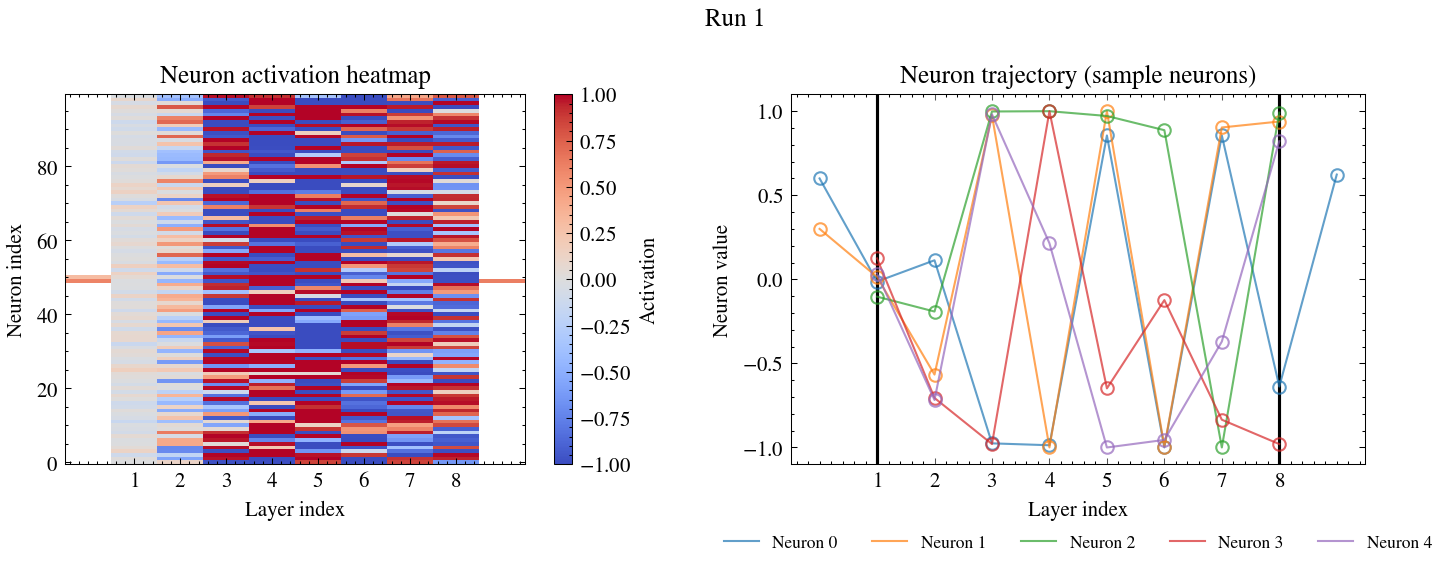

[0.6 0.3] →  [0.62298999]


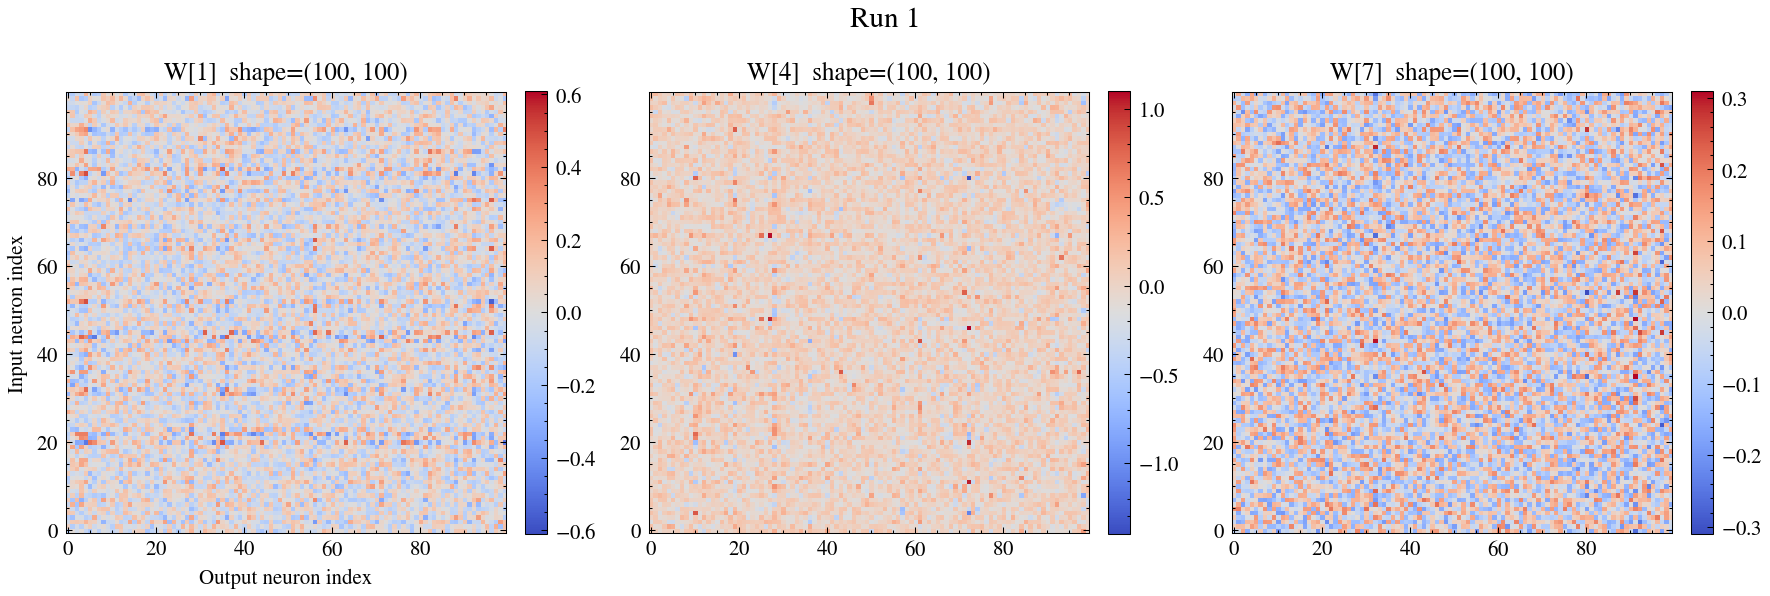

layer 0, reshaping into 2x100
Loaded layer 0: W(2, 100), B(100,)
layer 1, reshaping into 100x100
Loaded layer 1: W(100, 100), B(100,)
layer 2, reshaping into 100x100
Loaded layer 2: W(100, 100), B(100,)
layer 3, reshaping into 100x100
Loaded layer 3: W(100, 100), B(100,)
layer 4, reshaping into 100x100
Loaded layer 4: W(100, 100), B(100,)
layer 5, reshaping into 100x100
Loaded layer 5: W(100, 100), B(100,)
layer 6, reshaping into 100x100
Loaded layer 6: W(100, 100), B(100,)
layer 7, reshaping into 100x100
Loaded layer 7: W(100, 100), B(100,)
layer 8, reshaping into 100x1
Loaded layer 8: W(100, 1), B(1,)


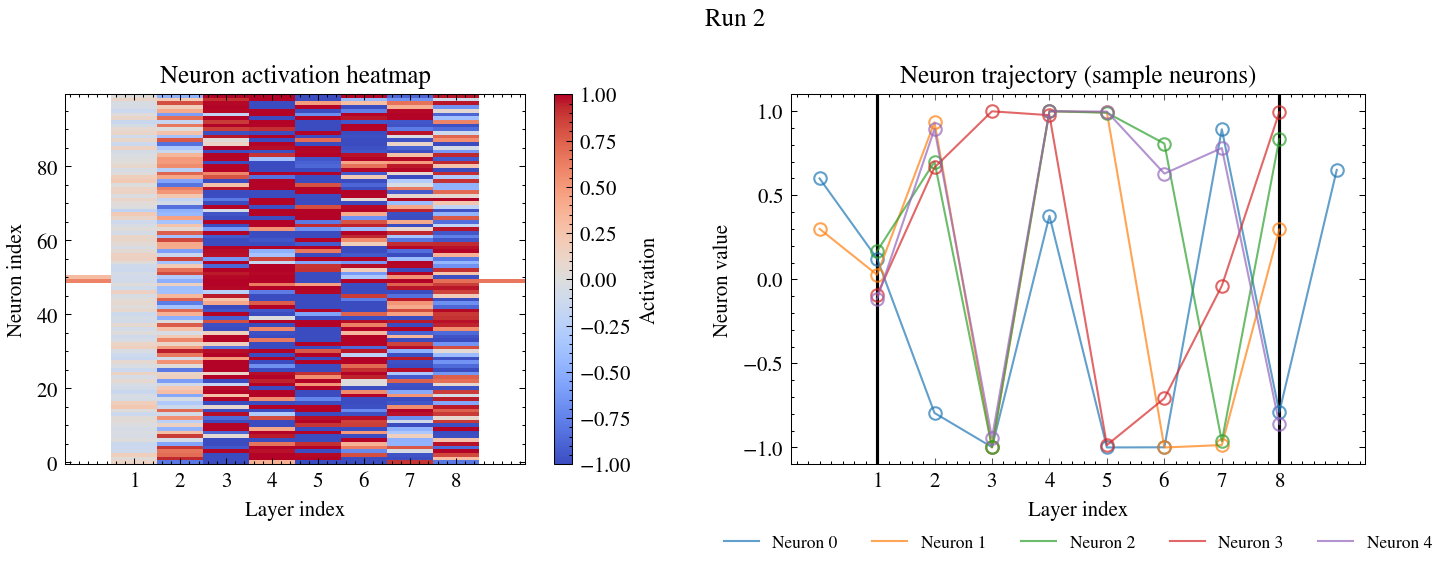

[0.6 0.3] →  [0.65081976]


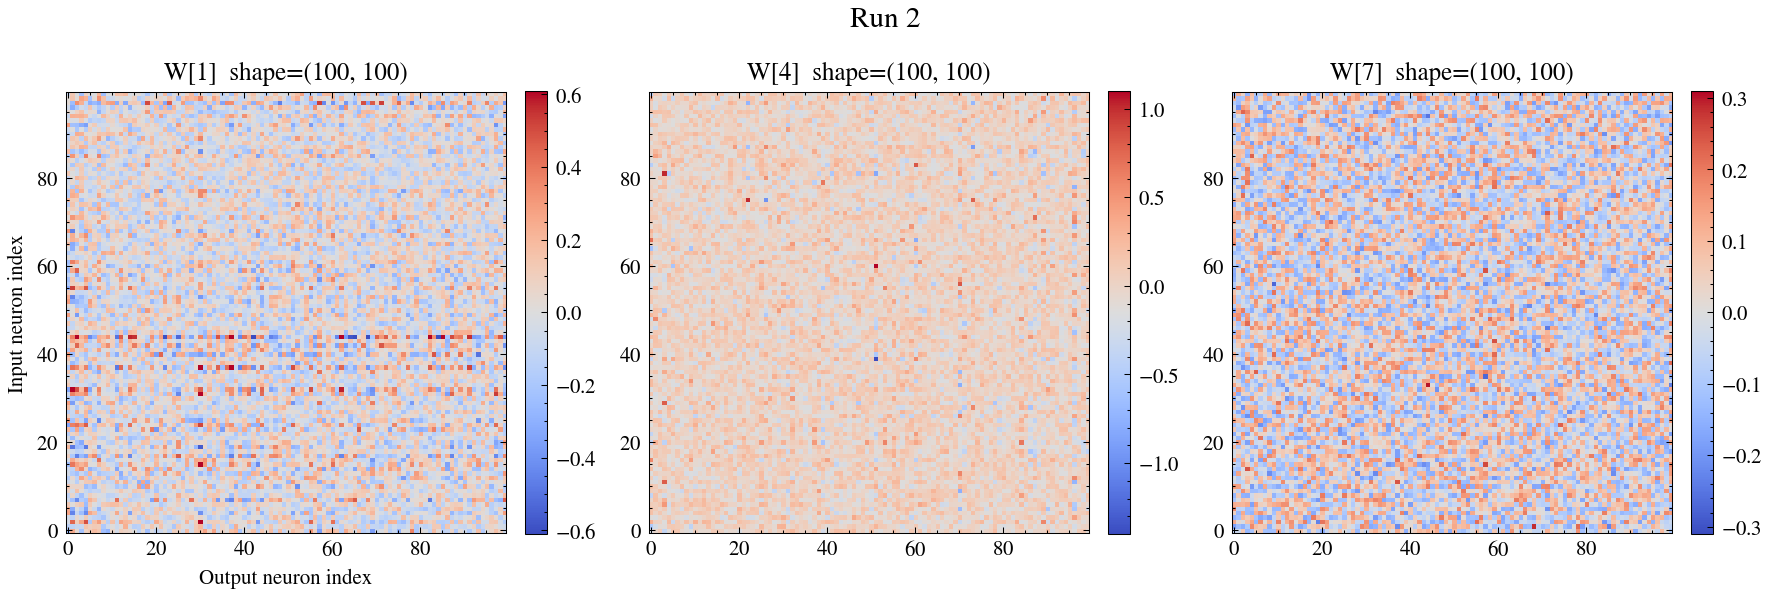

layer 0, reshaping into 2x100
Loaded layer 0: W(2, 100), B(100,)
layer 1, reshaping into 100x100
Loaded layer 1: W(100, 100), B(100,)
layer 2, reshaping into 100x100
Loaded layer 2: W(100, 100), B(100,)
layer 3, reshaping into 100x100
Loaded layer 3: W(100, 100), B(100,)
layer 4, reshaping into 100x100
Loaded layer 4: W(100, 100), B(100,)
layer 5, reshaping into 100x100
Loaded layer 5: W(100, 100), B(100,)
layer 6, reshaping into 100x100
Loaded layer 6: W(100, 100), B(100,)
layer 7, reshaping into 100x100
Loaded layer 7: W(100, 100), B(100,)
layer 8, reshaping into 100x1
Loaded layer 8: W(100, 1), B(1,)
layer 0, reshaping into 2x100
Loaded layer 0: W(2, 100), B(100,)
layer 1, reshaping into 100x100
Loaded layer 1: W(100, 100), B(100,)
layer 2, reshaping into 100x100
Loaded layer 2: W(100, 100), B(100,)
layer 3, reshaping into 100x100
Loaded layer 3: W(100, 100), B(100,)
layer 4, reshaping into 100x100
Loaded layer 4: W(100, 100), B(100,)
layer 5, reshaping into 100x100
Loaded layer 5: 

/tmp/ipykernel_4086935/1853195878.py:269: RuntimeWarning: Mean of empty slice
  z_mean = np.nanmean(z_mats, axis=0)
/home/abhixhek/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --------------------------------------------
# Network architecture
# --------------------------------------------
layer_sizes = [2, 100, 100, 100, 100, 100, 100, 100, 100, 1]
NL = len(layer_sizes) -1 # number of layers
normalize = False
pblend = 1.0

# --------------------------------------------
# Activation
# --------------------------------------------
def activation(x, pblend=1.0):
    return np.tanh(pblend * x)

# --------------------------------------------
# Load weights & biases
# --------------------------------------------
def load_layer_params(layer_idx, run):
    """Load weights and biases for one layer."""
    w_file = f"./weights/weights_riemann/run{run}/weights_burgers_run{run}_layer{layer_idx}.txt"
    b_file = f"./weights/weights_riemann/run{run}/biases_burgers_run{run}_layer{layer_idx}.txt"

    # Load weights & biases while skipping header lines starting with '#'
    W_flat = np.loadtxt(w_file, comments="#")
    B_flat = np.loadtxt(b_file, comments="#")

    fan_in, fan_out = layer_sizes[layer_idx], layer_sizes[layer_idx + 1]
    # print(f"layer {layer_idx}, reshaping into {fan_in}x{fan_out}")
    # Reshape weights: (fan_in, fan_out)
    W = W_flat.reshape(fan_in, fan_out)
    B = B_flat.reshape(fan_out)
    return W, B



def model_chain(x,t,plot='no', run = None):
    # Load all layers
    W, B = [], []
    for l in range(NL):
        Wi, Bi = load_layer_params(l,run)
        W.append(Wi)
        B.append(Bi)
        print(f"Loaded layer {l}: W{Wi.shape}, B{Bi.shape}")

    # --------------------------------------------
    # Single trajectory evolution
    # --------------------------------------------
    z = [None] * (NL+1)
    x_rand = x
    t_fixed = t                           
    z[0] = np.array([x_rand, t_fixed])
    if normalize:
        z[0] /= np.sum(np.abs(z[0]))

    for l in range(NL):

        zarg = z[l] @ W[l] + B[l]  

        # Apply tanh activation for all hidden layers (except last)
        if l < NL - 1:
            z[l + 1] = activation(zarg, pblend)
        else:
            z[l + 1] = zarg  # last layer is linear (no activation)

        if normalize:
            znorm = np.sum(np.abs(z[l + 1])) + 1e-12
            z[l + 1] /= znorm

    # --------------------------------------------
    # Build activation matrix (always)
    # --------------------------------------------
    max_neurons = max(len(zl) for zl in z)
    z_mat = np.full((len(z), max_neurons), np.nan)

    for i, zl in enumerate(z):
        n = len(zl)
        pad_top = (max_neurons - n) // 2
        pad_bottom = max_neurons - n - pad_top
        z_mat[i, pad_top:max_neurons - pad_bottom] = zl

    # --------------------------------------------
    # Visualization
    # --------------------------------------------
    if plot == 'yes':

        fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True)


        im = axs[0].imshow(z_mat.T, aspect='auto', cmap='coolwarm', origin='lower')
        fig.colorbar(im, ax=axs[0], label='Activation')

        axs[0].set_xlabel("Layer index")
        axs[0].set_ylabel("Neuron index")
        axs[0].set_title("Neuron activation heatmap")


        layer_indices = np.arange(1, 9)  # x = 1,2,...,8
        axs[1].set_xticks(layer_indices)


        for x in layer_indices:
            if x == layer_indices[0] or x == layer_indices[-1]:
                axs[1].axvline(x, color='black', linewidth=1.5)
            else:
                axs[1].axvline(x, color='white', alpha=0.4, linewidth=0.8)
        
        # Trajectories of sample neurons
        colors = plt.cm.tab10.colors

        for i in range(min(5, len(z[1]))):
            traj = [zl[i] if i < len(zl) else np.nan for zl in z]
            
            # Convert to array so we can mask
            traj = np.array(traj, dtype=float)
            # traj[0] = np.nan
            # traj[-1] = np.nan
            axs[1].plot(range(len(z)), traj, '-', color=colors[i], alpha=0.7, label=f'Neuron {i}')
            axs[1].plot(range(len(z)), traj, 'o', mfc='None', mec=colors[i], alpha=0.7)

        axs[1].set_xlabel("Layer index")
        axs[1].set_ylabel("Neuron value")
        axs[1].set_title("Neuron trajectory (sample neurons)")


        axs[1].legend(fontsize='small', ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.15))

        # # --------------------------------------------
        # # z vs neuron index (spatial profile evolution)
        # # --------------------------------------------
        # layer_start = 1   # shallow layer
        # layer_end   = 8   # deep layer

        # z_start = z[layer_start]
        # z_end   = z[layer_end]

        # x_axis = np.arange(len(z_start))

        # axs[1].plot(x_axis, z_start, '-', color='red', label=f'Layer {layer_start}', alpha=0.45)
        # axs[1].plot(x_axis, z_end, '-', color='blue', label=f'Layer {layer_end}', alpha=0.45)

        # axs[1].set_xlabel("Neuron index (space)")
        # axs[1].set_ylabel("Activation z")
        # axs[1].set_title("Evolution of z(x, t) across layers")

        # axs[1].legend()



        fig.suptitle(f"Run {run}", fontsize=12)
        plt.tight_layout()
        plt.show()

        print(f"{z[0]} →  {z[-1]}")


        # --------------------------------------------
        # Weight matrix visualization (Heatmaps)
        # --------------------------------------------
        fig_w, axs_w = plt.subplots(1, 3, figsize=(12, 4))

        axs_w = axs_w.flatten()

        l = 0
        layer = 1
        Wi = W[layer]
        im = axs_w[l].imshow(Wi, aspect='auto', cmap='coolwarm', origin='lower', vmin=-0.61 , vmax = 0.61 )
        axs_w[l].set_title(f"W[{layer}]  shape={Wi.shape}")
        axs_w[l].set_xlabel("Output neuron index")
        axs_w[l].set_ylabel("Input neuron index")
        axs_w[l].set_aspect('equal', adjustable='box')  
        fig_w.colorbar(im, ax=axs_w[l], fraction=0.046, pad=0.04)


        l = 1
        layer = 4
        Wi = W[layer]
        im = axs_w[l].imshow(Wi, aspect='auto', cmap='coolwarm', origin='lower', vmin=-1.4 , vmax = 1.1 )
        axs_w[l].set_title(f"W[{layer}]  shape={Wi.shape}")
        axs_w[l].set_aspect('equal', adjustable='box')  
        fig_w.colorbar(im, ax=axs_w[l], fraction=0.046, pad=0.04)


        l = 2
        layer = 7
        Wi = W[layer]
        im = axs_w[l].imshow(Wi, aspect='auto',cmap='coolwarm', origin='lower', vmin=-0.31 , vmax = 0.31 )
        axs_w[l].set_title(f"W[{layer}]  shape={Wi.shape}")
        axs_w[l].set_aspect('equal', adjustable='box')  
        fig_w.colorbar(im, ax=axs_w[l], fraction=0.046, pad=0.04)




        # Hide unused subplots if any
        for ax in axs_w[len(W):]:
            ax.axis('off')

        fig_w.suptitle(f"Run {run}", fontsize=14)
        plt.tight_layout()
        plt.show()




    return z[-1], z_mat

u_1,z_mat1 = model_chain(0.6,0.3,plot='yes',run = 1) 
u_2,z_mat2 = model_chain(0.6,0.3,plot='yes',run = 2) 

runs = range(1, 11)

z_mats = []

for run in runs:

    _, z_mat = model_chain(
        0.6,
        0.3,
        plot='no',
        run=run
    )

    z_mats.append(z_mat)

z_mats = np.array(z_mats)
print(f"z_mats.shape = {z_mats.shape}")  # should be (num_runs, num_layers, max_neurons)
# ------------------------------------------------
# Ensemble statistics
# ------------------------------------------------
z_mean = np.nanmean(z_mats, axis=0)
z_std  = np.nanstd(z_mats, axis=0)

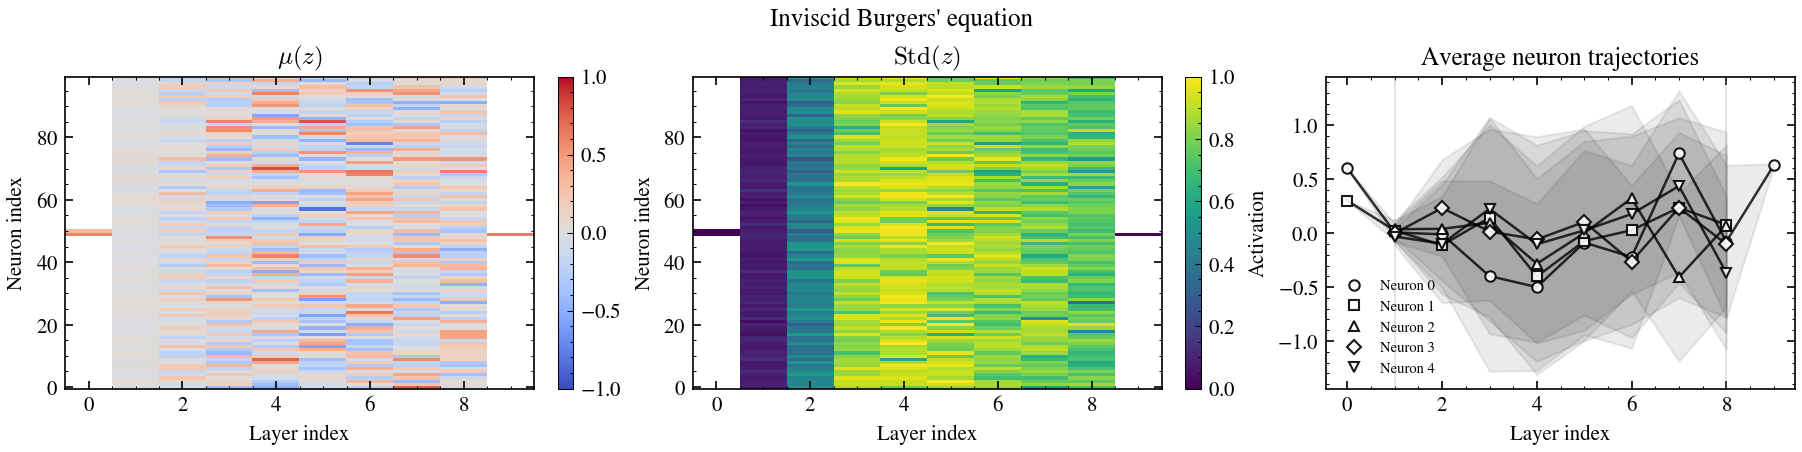

In [ ]:
# ------------------------------------------------------------
# Combined activation statistics figure
# [1] Mean activation heatmap
# [2] Activation std-dev heatmap
# [3] Ensemble neuron trajectories
# ------------------------------------------------------------

fig, axs = plt.subplots(
    1, 3,
    figsize=(12, 3),
    constrained_layout=True
)

# ============================================================
# [1] Mean activation heatmap
# ============================================================
im0 = axs[0].imshow(
    z_mean.T,
    aspect='auto',
    cmap='coolwarm',
    origin='lower',vmin=-1, vmax=1
)

axs[0].set_title(r'$\mu(z)$')

axs[0].set_xlabel("Layer index")
axs[0].set_ylabel("Neuron index")

fig.colorbar(
    im0,
    ax=axs[0],
    fraction=0.046
)

# ============================================================
# [2] Activation std-dev heatmap
# ============================================================
im1 = axs[1].imshow(
    z_std.T,
    aspect='auto',
    cmap='viridis',
    origin='lower',vmin=0, vmax=1
)

axs[1].set_title(
    r'$\operatorname{Std}(z)$'
)

axs[1].set_xlabel("Layer index")
axs[1].set_ylabel("Neuron index")

fig.colorbar(
    im1,
    ax=axs[1],
    fraction=0.046
)

# ============================================================
# [3] Ensemble neuron trajectories
# ============================================================
ax = axs[2]

layer_indices = np.arange(z_mean.shape[0])

for x in [1, 8]:
    ax.axvline(
        x,
        color='gray',
        alpha=0.25,
        linewidth=0.8
    )
# ------------------------------------------------------------
# Neurons to track
# ------------------------------------------------------------
sample_neurons = [0, 1, 2, 3, 4]

markers = ['o', 's', '^', 'D', 'v']

for k, neuron_id in enumerate(sample_neurons):

    traj_mean = []
    traj_std  = []

    for l in range(z_mean.shape[0]):

        # valid neurons in this layer
        valid = ~np.isnan(z_mean[l])

        valid_indices = np.where(valid)[0]

        # skip if neuron index exceeds layer width
        if neuron_id >= len(valid_indices):

            traj_mean.append(np.nan)
            traj_std.append(np.nan)

            continue

        idx = valid_indices[neuron_id]

        traj_mean.append(z_mean[l, idx])
        traj_std.append(z_std[l, idx])

    traj_mean = np.array(traj_mean)
    traj_std  = np.array(traj_std)

    # --------------------------------------------------------
    # Mean trajectory
    # --------------------------------------------------------
    ax.plot(
        layer_indices,
        traj_mean,
        '-',
        color='black',
        linewidth=1.2,
        alpha=0.8
    )

    # markers
    ax.plot(
        layer_indices,
        traj_mean,
        markers[k],
        mfc='white',
        mec='black',
        color='black',
        linestyle='none',
        markersize=5,
        alpha=0.9,
        label=f'Neuron {neuron_id}'
    )

    # --------------------------------------------------------
    # Std-dev band
    # --------------------------------------------------------
    ax.fill_between(
        layer_indices,
        traj_mean - traj_std,
        traj_mean + traj_std,
        color='black',
        alpha=0.08
    )

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------
ax.set_xlabel("Layer index")

ax.set_ylabel("Activation")

ax.set_title(
    "Average neuron trajectories"
)

ax.legend(
    ncol=1,
    fontsize=7,
    frameon=False
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
for ax in axs.flatten():

    ax.tick_params(
        direction='in',
        length=4,
        width=0.8
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

# ------------------------------------------------------------
# Show
# ------------------------------------------------------------
plt.suptitle("Inviscid Burgers' equation", fontsize=12)
plt.show()

In [ ]:
x = np.linspace(0,1,100)
t = 0.3
u_1 = np.zeros_like(x)
u_2 = np.zeros_like(x)
u_3 = np.zeros_like(x)
u_4 = np.zeros_like(x)
u_5 = np.zeros_like(x)
u_6 = np.zeros_like(x)
u_7 = np.zeros_like(x)
u_8 = np.zeros_like(x)
u_9 = np.zeros_like(x)
u_10 = np.zeros_like(x)
for idx in range (len(x)):
    a1,_ =  model_chain(x[idx],t, plot='no',run=1)
    a2,_ =  model_chain(x[idx],t, plot='no',run=2)
    a3,_ =  model_chain(x[idx],t, plot='no',run=3)
    a4,_ =  model_chain(x[idx],t, plot='no',run=4)
    a5,_ =  model_chain(x[idx],t, plot='no',run=5)
    a6,_ =  model_chain(x[idx],t, plot='no',run=6)
    a7,_ =  model_chain(x[idx],t, plot='no',run=7)
    a8,_ =  model_chain(x[idx],t, plot='no',run=8)
    a9,_ =  model_chain(x[idx],t, plot='no',run=9)
    a10,_ =  model_chain(x[idx],t, plot='no',run=10)
    u_1[idx] = a1.squeeze()
    u_2[idx] = a2.squeeze()
    u_3[idx] = a3.squeeze()
    u_4[idx] = a4.squeeze()
    u_5[idx] = a5.squeeze()
    u_6[idx] = a6.squeeze()
    u_7[idx] = a7.squeeze()
    u_8[idx] = a8.squeeze()
    u_9[idx] = a9.squeeze()
    u_10[idx] = a10.squeeze()

layer 0, reshaping into 2x100
Loaded layer 0: W(2, 100), B(100,)
layer 1, reshaping into 100x100
Loaded layer 1: W(100, 100), B(100,)
layer 2, reshaping into 100x100
Loaded layer 2: W(100, 100), B(100,)
layer 3, reshaping into 100x100
Loaded layer 3: W(100, 100), B(100,)
layer 4, reshaping into 100x100
Loaded layer 4: W(100, 100), B(100,)
layer 5, reshaping into 100x100
Loaded layer 5: W(100, 100), B(100,)
layer 6, reshaping into 100x100
Loaded layer 6: W(100, 100), B(100,)
layer 7, reshaping into 100x100
Loaded layer 7: W(100, 100), B(100,)
layer 8, reshaping into 100x1
Loaded layer 8: W(100, 1), B(1,)
layer 0, reshaping into 2x100
Loaded layer 0: W(2, 100), B(100,)
layer 1, reshaping into 100x100
Loaded layer 1: W(100, 100), B(100,)
layer 2, reshaping into 100x100
Loaded layer 2: W(100, 100), B(100,)
layer 3, reshaping into 100x100
Loaded layer 3: W(100, 100), B(100,)
layer 4, reshaping into 100x100
Loaded layer 4: W(100, 100), B(100,)
layer 5, reshaping into 100x100
Loaded layer 5: 

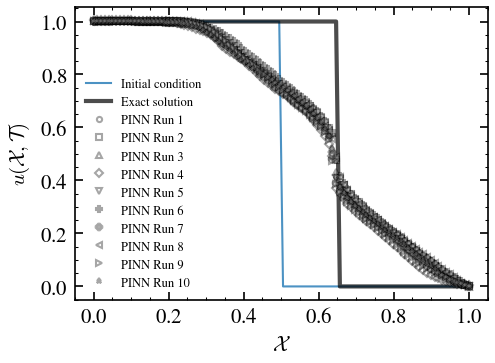

In [ ]:

def riemann_function(X, left_val=1.0, right_val=0.0, discont=0.5):
    F = np.where(X < discont, left_val, right_val)
    scale = np.max(np.abs(F))          # scalar: max absolute value
    if scale == 0:
        return F                       # avoid division by zero (all zero)
    return F / scale

def exact_riemann_solution(x, t):
    left_val = 1
    right_val = 0 
    discont = 0.5
    u_exact = np.zeros_like(x)

    if left_val > right_val:
        # Shock
        s = 0.5 * (left_val + right_val)
        for i in range(len(x)):
            if x[i] < discont + s * t:
                u_exact[i] = left_val
            else:
                u_exact[i] = right_val
    elif left_val < right_val:
        # Rarefaction
        for i in range(len(x)):
            xi = (x[i] - discont) / t if t > 0 else np.inf
            if xi < left_val:
                u_exact[i] = left_val
            elif xi > right_val:
                u_exact[i] = right_val
            else:
                u_exact[i] = xi
    else:
        # Constant state
        u_exact[:] = left_val

    return u_exact
u_exact = exact_riemann_solution(x, t)


# ------------------------------------------------------------
# Predictions from 10 independent runs
# ------------------------------------------------------------

# Collect predictions
u_runs = [u_1, u_2, u_3, u_4, u_5,
          u_6, u_7, u_8, u_9, u_10]

# 10 distinct markers
markers = ['o', 's', '^', 'D', 'v',
           'P', 'X', '<', '>', '*']

# ------------------------------------------------------------
# Reference solutions
# ------------------------------------------------------------
plt.plot(
    x,
    riemann_function(x),
    '-',
    color='tab:blue',
    linewidth=1,
    alpha=0.8,
    label='Initial condition',
    zorder=1
)

plt.plot(
    x,
    u_exact,
    '-',
    color='black',
    linewidth=2,
    alpha=0.7,
    label='Exact solution',
    zorder=2
)

# ------------------------------------------------------------
# PINN predictions
# ------------------------------------------------------------
for run_idx, u_pred in enumerate(u_runs):

    plt.plot(
        x,
        u_pred,
        markers[run_idx],
        mfc='white',
        mec='black',
        color='green',
        linestyle='none',
        markersize=2.5,
        alpha=0.35,
        label=f'PINN Run {run_idx+1}',
        zorder=3
    )

# ------------------------------------------------------------
# Labels / legend
# ------------------------------------------------------------
plt.xlabel('$\\mathcal{X}$')
plt.ylabel('$u(\\mathcal{X}, \\mathcal{T})$')

plt.legend(fontsize=6, ncol=1, loc='lower left')

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax = plt.gca()

ax.tick_params(
    direction='in',
    length=4,
    width=0.8
)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()









In [ ]:
from tabulate import tabulate

def compute_norms(u_pred, u_ref):
    err = np.abs(u_pred - u_ref)
    L1   = np.mean(err) 
    L2   = np.sqrt(np.mean((u_pred - u_ref)**2))   
    Linf = np.max(err)
    return L1, L2, Linf

# Compute errors
L1_1, L2_1, Linf_1 = compute_norms(u_1, u_exact.flatten())
L1_2, L2_2, Linf_2 = compute_norms(u_2, u_exact.flatten())
L1_3, L2_3, Linf_3 = compute_norms(u_3, u_exact.flatten())
L1_4, L2_4, Linf_4 = compute_norms(u_4, u_exact.flatten())
L1_5, L2_5, Linf_5 = compute_norms(u_5, u_exact.flatten())
L1_6, L2_6, Linf_6 = compute_norms(u_6, u_exact.flatten())
L1_7, L2_7, Linf_7 = compute_norms(u_7, u_exact.flatten())
L1_8, L2_8, Linf_8 = compute_norms(u_8, u_exact.flatten())
L1_9, L2_9, Linf_9 = compute_norms(u_9, u_exact.flatten())
L1_10, L2_10, Linf_10 = compute_norms(u_10, u_exact.flatten())

table = [
    ["PINN Run 1", f"{L1_1:.6f}", f"{L2_1:.6f}", f"{Linf_1:.6f}"],
    ["PINN Run 2", f"{L1_2:.6f}", f"{L2_2:.6f}", f"{Linf_2:.6f}"],
    ["PINN Run 3", f"{L1_3:.6f}", f"{L2_3:.6f}", f"{Linf_3:.6f}"],
    ["PINN Run 4", f"{L1_4:.6f}", f"{L2_4:.6f}", f"{Linf_4:.6f}"],
    ["PINN Run 5", f"{L1_5:.6f}", f"{L2_5:.6f}", f"{Linf_5:.6f}"],
    ["PINN Run 6", f"{L1_6:.6f}", f"{L2_6:.6f}", f"{Linf_6:.6f}"],
    ["PINN Run 7", f"{L1_7:.6f}", f"{L2_7:.6f}", f"{Linf_7:.6f}"],
    ["PINN Run 8", f"{L1_8:.6f}", f"{L2_8:.6f}", f"{Linf_8:.6f}"],
    ["PINN Run 9", f"{L1_9:.6f}", f"{L2_9:.6f}", f"{Linf_9:.6f}"],
    ["PINN Run 10", f"{L1_10:.6f}", f"{L2_10:.6f}", f"{Linf_10:.6f}"],
]
print("Inviscid Burgers' equation")
print(tabulate(table, headers=["Method", "L1 Error", "L2 Error", "L-inf Error"], 
               tablefmt="github"))

Inviscid Burgers' equation
| Method      |   L¹ Error |   L² Error |   L∞ Error |
|-------------|------------|------------|------------|
| PINN Run 1  |   0.13872  |   0.197293 |   0.585565 |
| PINN Run 2  |   0.138301 |   0.193387 |   0.522046 |
| PINN Run 3  |   0.141161 |   0.197108 |   0.569207 |
| PINN Run 4  |   0.138181 |   0.198417 |   0.630228 |
| PINN Run 5  |   0.142467 |   0.200212 |   0.592581 |
| PINN Run 6  |   0.135043 |   0.190978 |   0.523341 |
| PINN Run 7  |   0.140449 |   0.200127 |   0.609075 |
| PINN Run 8  |   0.141963 |   0.197217 |   0.512315 |
| PINN Run 9  |   0.135017 |   0.195851 |   0.614231 |
| PINN Run 10 |   0.140794 |   0.196629 |   0.584711 |


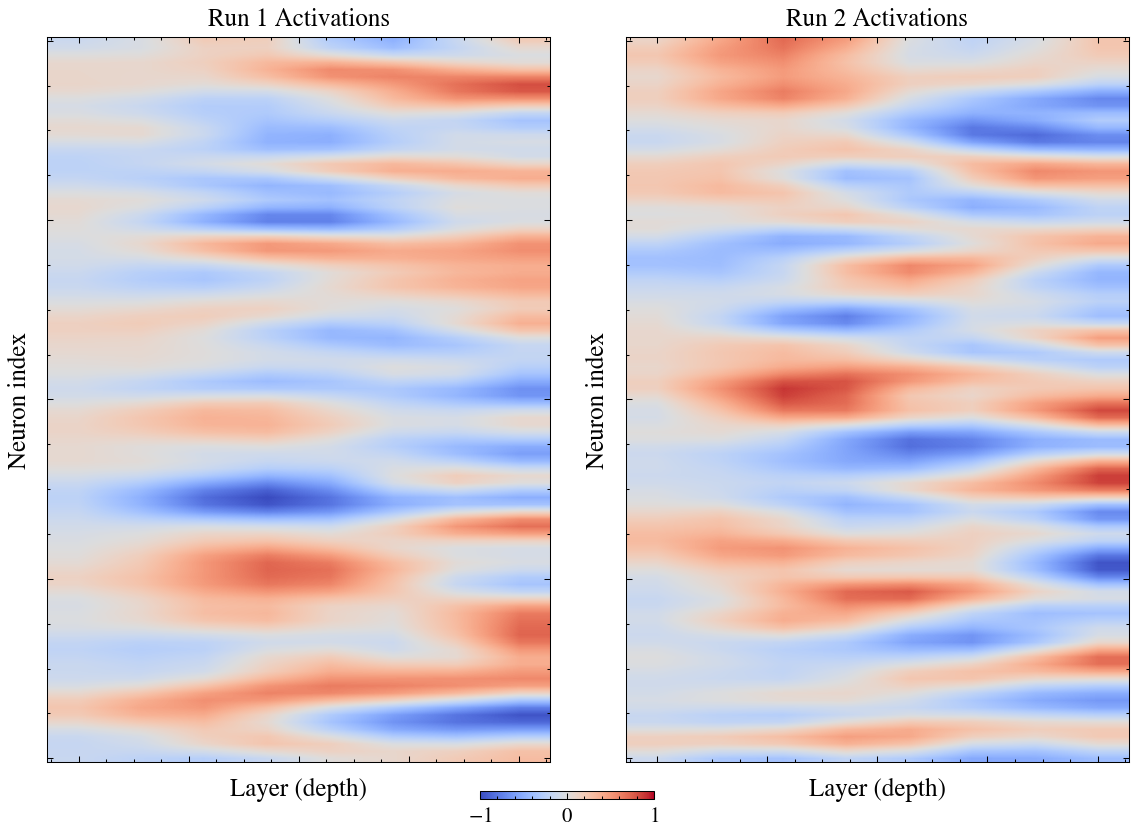

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.ndimage import gaussian_filter, zoom

# =========================
# FUNCTION TO PROCESS DATA
# =========================

def process(z_mat):
    z = z_mat[1:-1]                      # remove NaN layers
    z = np.nan_to_num(z, nan=0.0)

    orig_shape = z.shape  # store original size

    z = gaussian_filter(z, sigma=(1.2, 1.5))
    # z = zoom(z, (2, 2))                  # upsample

    z = z / np.max(np.abs(z))
    z = z - np.mean(z)

    return z, orig_shape

z1, shape1 = process(z_mat1)
z2, shape2 = process(z_mat2)

orig_layers, orig_neurons = shape1

# =========================
# GLOBAL NORMALIZATION
# =========================

zmin = min(z1.min(), z2.min())
zmax = max(z1.max(), z2.max())

norm = mpl.colors.Normalize(vmin=-1, vmax=1)
cmap = plt.cm.coolwarm

# =========================
# FIGURE
# =========================

fig, axes = plt.subplots(1, 2, figsize=(8.0139, 6.2739))

titles = ["Run 1 Activations", "Run 2 Activations"]
data = [z1.T, z2.T]

for ax, z, title in zip(axes, data, titles):

    im = ax.imshow(
        z,
        aspect='auto',
        origin='lower',
        cmap=cmap,
        norm=norm,interpolation='bilinear'
    )

    # -------------------------
    # TICKS 
    # -------------------------

    xticks = np.linspace(0, z.shape[1]-1, 5)
    yticks = np.linspace(0, z.shape[0]-1, 5)

    xtick_labels = [f"{int(i)}" for i in np.linspace(0, orig_neurons-1, 5)]
    ytick_labels = [f"{int(i)}" for i in np.linspace(0, orig_layers-1, 5)]

    xtick_labels = []
    ytick_labels = []

    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=5)

    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels, fontsize=5)

    ax.set_title(title, fontsize=12)

# =========================
# SHARED COLORBAR
# =========================

mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

cbar = fig.colorbar(
    mappable,
    ax=axes,
    orientation='horizontal',
    fraction=0.012,  
    pad=0.1,         
)


# =========================
# LABELS
# =========================

for ax in axes:
    ax.set_ylabel("Neuron index", fontsize=12)
    ax.set_xlabel("Layer (depth)", fontsize=12)


plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.15,
    top=0.92,
    wspace=0.15
)

# =========================
# SAVE
# =========================


plt.show()
plt.close()